# Cache Experiment — C1 Prompt Cache + C2 Semantic Cache
Runs both cache experiments and saves rendered charts for thesis documentation.

**Output files in `cache_renders/`:**
- `c1_run01-05.png` — rendered charts from each C1 run
- `c1_latency_comparison.png` — C1 bar chart
- `c1_all_runs_grid.png` — C1 5-panel grid
- `c2_*.png` — rendered chart per query
- `c2_hit_vs_miss_comparison.png` — key C2 comparison figure
- `c2_all_queries_grid.png` — C2 8-panel grid

## Cell 1 — Setup

In [1]:
import sys, os, time, json, copy
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

CANDIDATES = [
    "/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch",
    os.path.abspath(".."), os.getcwd(),
]
PROJECT_ROOT = next(
    (p for p in CANDIDATES if os.path.isfile(os.path.join(p, "generate_visualization.py"))), None
)
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from retrieve_data import retrieve_data
from generate_visualization import Agent
from init_phoenix import init_phoenix
from visualization_from_template import generate_from_template

import phoenix as px
if not hasattr(px, "_thesis_initialised"):
    client, tool_calling_client, tracer = init_phoenix("cache-visualization")
    px._thesis_initialised = True
    px._thesis_client = client
    px._thesis_tool_client = tool_calling_client
    px._thesis_tracer = tracer
else:
    client = px._thesis_client
    tool_calling_client = px._thesis_tool_client
    tracer = px._thesis_tracer

MD_TABLE = retrieve_data(None, type="test")
QUESTION = (
    "Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? "
    "Provide a detailed analysis and a comprehensive visualization."
)

os.makedirs("cache_renders", exist_ok=True)
print(f"Setup OK — project root: {PROJECT_ROOT}")


🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: cache-visualization
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: http://localhost:6006/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.

Setup OK — project root: /Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch


## Cell 2 — C1: Run 5 identical queries

In [2]:
# ═══════════════════════════════════════════
# C1 — Prompt Cache: 5 identical runs
# ═══════════════════════════════════════════

agent = Agent(client, tool_calling_client, tracer, "o4-mini")

c1_results = []
print("Running C1: 5 identical runs (same exact question each time)...")
print("-" * 55)

for i in range(5):
    t0 = time.time()
    response = agent.start_main_span([
        {"role": "user",   "content": QUESTION},
        {"role": "system", "content": f"The data is: {MD_TABLE}"},
    ])
    t = round(time.time() - t0, 3)

    # extract config
    cfg = None
    if isinstance(response, dict) and "content" in response:
        c = response["content"]
        cfg = json.loads(c) if isinstance(c, str) else c
    else:
        cfg = response

    # render and save
    fname = f"cache_renders/c1_run{i+1:02d}.png"
    try:
        plt.close("all")
        generate_from_template(copy.deepcopy(cfg))
        plt.savefig(fname, dpi=120, bbox_inches="tight")
        plt.close("all")
        rendered = True
    except Exception as e:
        rendered = False
        print(f"  Render error run {i+1}: {e}")

    label = "Cold" if i == 0 else f"Warm {i}"
    c1_results.append({"run": i+1, "latency_s": t, "label": label, "rendered": rendered,
                        "charttype": cfg.get("charttype","?") if cfg else "?"})
    print(f"  Run {i+1} [{label}]: {t:.2f}s  chart={cfg.get('charttype','?') if cfg else '?'}  saved={fname}")

print(f"\nC1 done. Latencies: {[r['latency_s'] for r in c1_results]}")


Running C1: 5 identical runs (same exact question each time)...
-------------------------------------------------------
Starting main span with messages: [{'role': 'user', 'content': 'Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a detailed analysis and a comprehensive visualization.'}, {'role': 'system', 'content': 'The data is: \n        |   Kalender[Jahr] | Kalender[Monat]   |   [Umsatz SD/CO] |\n        |-----------------:|:------------------|-----------------:|\n        |             2021 | Apr               |         30264.05 |\n        |             2021 | Aug               |          9660.99 |\n        |             2021 | Dez               |         31104.06 |\n        |             2021 | Feb               |         11619.17 |\n        |             2021 | Jan               |         12308.10 |\n        |             2021 | Jul               |          4399.77 |\n        |             2021 | Jun               |         12705.90 |\n       

/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/visualization_from_template.py:398: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  Run 1 [Cold]: 49.83s  chart=line  saved=cache_renders/c1_run01.png
Starting main span with messages: [{'role': 'user', 'content': 'Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a detailed analysis and a comprehensive visualization.'}, {'role': 'system', 'content': 'The data is: \n        |   Kalender[Jahr] | Kalender[Monat]   |   [Umsatz SD/CO] |\n        |-----------------:|:------------------|-----------------:|\n        |             2021 | Apr               |         30264.05 |\n        |             2021 | Aug               |          9660.99 |\n        |             2021 | Dez               |         31104.06 |\n        |             2021 | Feb               |         11619.17 |\n        |             2021 | Jan               |         12308.10 |\n        |             2021 | Jul               |          4399.77 |\n        |             2021 | Jun               |         12705.90 |\n        |             2021 | Mai               |          

/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/visualization_from_template.py:398: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  Run 2 [Warm 1]: 44.41s  chart=line  saved=cache_renders/c1_run02.png
Starting main span with messages: [{'role': 'user', 'content': 'Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a detailed analysis and a comprehensive visualization.'}, {'role': 'system', 'content': 'The data is: \n        |   Kalender[Jahr] | Kalender[Monat]   |   [Umsatz SD/CO] |\n        |-----------------:|:------------------|-----------------:|\n        |             2021 | Apr               |         30264.05 |\n        |             2021 | Aug               |          9660.99 |\n        |             2021 | Dez               |         31104.06 |\n        |             2021 | Feb               |         11619.17 |\n        |             2021 | Jan               |         12308.10 |\n        |             2021 | Jul               |          4399.77 |\n        |             2021 | Jun               |         12705.90 |\n        |             2021 | Mai               |        

...

  Run 3 [Warm 2]: 51.48s  chart=line  saved=cache_renders/c1_run03.png
Starting main span with messages: [{'role': 'user', 'content': 'Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a detailed analysis and a comprehensive visualization.'}, {'role': 'system', 'content': 'The data is: \n        |   Kalender[Jahr] | Kalender[Monat]   |   [Umsatz SD/CO] |\n        |-----------------:|:------------------|-----------------:|\n        |             2021 | Apr               |         30264.05 |\n        |             2021 | Aug               |          9660.99 |\n        |             2021 | Dez               |         31104.06 |\n        |             2021 | Feb               |         11619.17 |\n        |             2021 | Jan               |         12308.10 |\n        |             2021 | Jul               |          4399.77 |\n        |             2021 | Jun               |         12705.90 |\n        |             2021 | Mai               |        

/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/visualization_from_template.py:398: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  Run 4 [Warm 3]: 44.11s  chart=line  saved=cache_renders/c1_run04.png
Starting main span with messages: [{'role': 'user', 'content': 'Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a detailed analysis and a comprehensive visualization.'}, {'role': 'system', 'content': 'The data is: \n        |   Kalender[Jahr] | Kalender[Monat]   |   [Umsatz SD/CO] |\n        |-----------------:|:------------------|-----------------:|\n        |             2021 | Apr               |         30264.05 |\n        |             2021 | Aug               |          9660.99 |\n        |             2021 | Dez               |         31104.06 |\n        |             2021 | Feb               |         11619.17 |\n        |             2021 | Jan               |         12308.10 |\n        |             2021 | Jul               |          4399.77 |\n        |             2021 | Jun               |         12705.90 |\n        |             2021 | Mai               |        

/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/visualization_from_template.py:398: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  Run 5 [Warm 4]: 51.93s  chart=line  saved=cache_renders/c1_run05.png

C1 done. Latencies: [49.827, 44.414, 51.481, 44.109, 51.926]


## Cell 3 — C1: Latency comparison chart

In [3]:
# ═══════════════════════════════════════════
# C1 — Plot: latency comparison
# ═══════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
runs   = [r["run"]       for r in c1_results]
lats   = [r["latency_s"] for r in c1_results]
labels = [r["label"]     for r in c1_results]
colors = ["#C0392B"] + ["#1D9E75"] * 4

bars = ax.bar(runs, lats, color=colors, edgecolor="white", width=0.6)
for bar, v, lbl in zip(bars, lats, labels):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{v:.1f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.text(bar.get_x()+bar.get_width()/2, -2.0,
            lbl, ha="center", va="top", fontsize=9,
            color="#C0392B" if lbl=="Cold" else "#1D9E75")

ax.set_xlabel("Run #", fontsize=11)
ax.set_ylabel("Latency (seconds)", fontsize=11)
ax.set_title("C1: OpenAI Prompt Cache — 5 Consecutive Identical Runs\no4-mini, same query each time",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, max(lats) * 1.25)
ax.set_xticks(runs)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

cold_patch = mpatches.Patch(color="#C0392B", label="Cold (no cache)")
warm_patch = mpatches.Patch(color="#1D9E75", label="Warm (prompt cached)")
ax.legend(handles=[cold_patch, warm_patch])

plt.tight_layout()
plt.savefig("cache_renders/c1_latency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cache_renders/c1_latency_comparison.png")


Saved: cache_renders/c1_latency_comparison.png


/var/folders/zy/jrpsl1v90xx47xwd7fws6np00000gn/T/ipykernel_77358/3297103622.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Cell 4 — C1: All 5 renders side by side

In [4]:
# ═══════════════════════════════════════════
# C1 — Show all 5 rendered charts side by side
# ═══════════════════════════════════════════
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle("C1: Prompt Cache — 5 Runs (same query, same model)\nAll charts should be structurally identical",
             fontsize=13, fontweight="bold")

for i, ax in enumerate(axes):
    fname = f"cache_renders/c1_run{i+1:02d}.png"
    r = c1_results[i]
    try:
        img = mpimg.imread(fname)
        ax.imshow(img)
        ax.set_title(f"Run {i+1} [{r['label']}]\n{r['latency_s']:.1f}s", fontsize=9, fontweight="bold",
                     color="#C0392B" if r["label"]=="Cold" else "#1D9E75")
    except:
        ax.text(0.5, 0.5, "No render", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"Run {i+1} — failed", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("cache_renders/c1_all_runs_grid.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: cache_renders/c1_all_runs_grid.png")


Saved: cache_renders/c1_all_runs_grid.png


/var/folders/zy/jrpsl1v90xx47xwd7fws6np00000gn/T/ipykernel_77358/230410224.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Cell 5 — C2: Semantic cache — 8 queries

In [5]:
# ═══════════════════════════════════════════
# C2 — Semantic Cache
# 8 queries: Q1 seed + paraphrases + different intent
# ═══════════════════════════════════════════
import hashlib, numpy as np
from openai import OpenAI

# Simple FAISS-based semantic cache
try:
    import faiss
    FAISS_OK = True
except ImportError:
    FAISS_OK = False
    print("FAISS not available — using cosine similarity manually")

# Use OpenAI embedding directly
openai_client = OpenAI()  # uses OPENAI_API_KEY from env

def embed(text):
    resp = openai_client.embeddings.create(
        model="text-embedding-3-small", input=text
    )
    return np.array(resp.data[0].embedding, dtype=np.float32)

def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# Semantic cache implementation
class SemanticCache:
    def __init__(self, threshold=0.75):
        self.threshold = threshold
        self.entries = []  # list of (embedding, config, query)

    def lookup(self, query_emb):
        best_sim, best_cfg = -1, None
        for emb, cfg, q in self.entries:
            sim = cosine_sim(query_emb, emb)
            if sim > best_sim:
                best_sim, best_cfg = sim, cfg
        if best_sim >= self.threshold:
            return best_cfg, best_sim
        return None, best_sim

    def store(self, query_emb, cfg, query):
        self.entries.append((query_emb, cfg, query))

cache = SemanticCache(threshold=0.75)

# Queries to test
QUERIES = [
    {"id":"Q1_seed",          "expected":"MISS", "text": QUESTION,
     "note":"Seed query — populates cache"},
    {"id":"Q2_similar_de",    "expected":"HIT",
     "text":"Wie hat sich der Umsatz von Teckentrup im JVA-Segment zwischen 2021 und 2024 entwickelt? Bitte analysiere die Daten und erstelle eine Visualisierung.",
     "note":"Same intent, different German wording"},
    {"id":"Q3_similar_en",    "expected":"HIT",
     "text":"What were the revenues of Teckentrup in the JVA segment from 2021 to 2024? Provide an analysis and a chart.",
     "note":"Same intent, English"},
    {"id":"Q4_similar_short", "expected":"HIT",
     "text":"Teckentrup JVA Umsatz 2021-2024 Visualisierung",
     "note":"Short paraphrase, German"},
    {"id":"Q5_similar_verbose","expected":"HIT",
     "text":"Kannst du mir den Umsatz der Teckentrup GmbH im Segment Justizvollzugsanstalten fuer die Geschaeftsjahre 2021, 2022, 2023 und 2024 zeigen und eine detaillierte Analyse mit Diagramm erstellen?",
     "note":"Verbose paraphrase, full JVA name"},
    {"id":"Q6_diff_year",     "expected":"MISS",
     "text":"Wieviel Umsatz hatte Teckentrup im Jahr 2022 im Segment JVA?",
     "note":"Different year range — different scope"},
    {"id":"Q7_diff_segment",  "expected":"MISS",
     "text":"Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im gesamten Unternehmen?",
     "note":"Different segment — whole company"},
    {"id":"Q8_diff_metric",   "expected":"MISS",
     "text":"Wie viele Auftraege hatte Teckentrup im JVA Segment 2021 bis 2024?",
     "note":"Different metric — orders not revenue"},
]

agent = Agent(client, tool_calling_client, tracer, "o4-mini")
c2_results = []

print(f"Running C2: Semantic Cache (threshold={cache.threshold})")
print("-" * 70)

for q in QUERIES:
    t0 = time.time()

    # embed query
    q_emb = embed(q["text"])

    # lookup cache
    cached_cfg, sim = cache.lookup(q_emb)
    hit = cached_cfg is not None

    if hit:
        # CACHE HIT — return cached config instantly
        cfg = cached_cfg
        t = round(time.time() - t0, 3)
        actual = "HIT"
        source = "cache"
    else:
        # CACHE MISS — call LLM
        response = agent.start_main_span([
            {"role": "user",   "content": q["text"]},
            {"role": "system", "content": f"The data is: {MD_TABLE}"},
        ])
        t = round(time.time() - t0, 3)
        actual = "MISS"
        source = "LLM"

        if isinstance(response, dict) and "content" in response:
            c = response["content"]
            cfg = json.loads(c) if isinstance(c, str) else c
        else:
            cfg = response

        # store in cache
        cache.store(q_emb, cfg, q["text"])

    # render and save
    fname = f"cache_renders/c2_{q['id']}.png"
    try:
        plt.close("all")
        generate_from_template(copy.deepcopy(cfg))
        plt.savefig(fname, dpi=120, bbox_inches="tight")
        plt.close("all")
        rendered = True
    except Exception as e:
        rendered = False

    correct = (actual == q["expected"])
    sim_str  = f"{sim:.3f}" if sim > -1 else "N/A"
    status   = "✓" if correct else "✗"
    print(f"  {q['id']:<22} expected={q['expected']}  actual={actual}  sim={sim_str}  {t:.2f}s  {status}  [{source}]")

    c2_results.append({
        "id": q["id"], "note": q["note"],
        "expected": q["expected"], "actual": actual,
        "correct": correct, "similarity": round(sim, 4) if sim > -1 else None,
        "latency_s": t, "source": source, "fname": fname, "rendered": rendered
    })

hits  = sum(1 for r in c2_results if r["actual"]=="HIT")
total = len(c2_results)
print(f"\nHit rate: {hits}/{total} ({hits/total*100:.0f}%)")
print(f"Correct:  {sum(r['correct'] for r in c2_results)}/{total}")


Running C2: Semantic Cache (threshold=0.75)
----------------------------------------------------------------------
Starting main span with messages: [{'role': 'user', 'content': 'Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a detailed analysis and a comprehensive visualization.'}, {'role': 'system', 'content': 'The data is: \n        |   Kalender[Jahr] | Kalender[Monat]   |   [Umsatz SD/CO] |\n        |-----------------:|:------------------|-----------------:|\n        |             2021 | Apr               |         30264.05 |\n        |             2021 | Aug               |          9660.99 |\n        |             2021 | Dez               |         31104.06 |\n        |             2021 | Feb               |         11619.17 |\n        |             2021 | Jan               |         12308.10 |\n        |             2021 | Jul               |          4399.77 |\n        |             2021 | Jun               |         12705.90 |\n        |   

/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/visualization_from_template.py:398: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  Q1_seed                expected=MISS  actual=MISS  sim=N/A  52.52s  ✓  [LLM]


/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/visualization_from_template.py:398: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  Q2_similar_de          expected=HIT  actual=HIT  sim=0.911  2.00s  ✓  [cache]


...

  Q4_similar_short       expected=HIT  actual=HIT  sim=0.826  0.27s  ✓  [cache]


/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/visualization_from_template.py:398: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  Q5_similar_verbose     expected=HIT  actual=HIT  sim=0.814  0.19s  ✓  [cache]


/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch/visualization_from_template.py:398: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  Q6_diff_year           expected=MISS  actual=HIT  sim=0.868  0.19s  ✗  [cache]
Starting main span with messages: [{'role': 'user', 'content': 'Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im gesamten Unternehmen?'}, {'role': 'system', 'content': 'The data is: \n        |   Kalender[Jahr] | Kalender[Monat]   |   [Umsatz SD/CO] |\n        |-----------------:|:------------------|-----------------:|\n        |             2021 | Apr               |         30264.05 |\n        |             2021 | Aug               |          9660.99 |\n        |             2021 | Dez               |         31104.06 |\n        |             2021 | Feb               |         11619.17 |\n        |             2021 | Jan               |         12308.10 |\n        |             2021 | Jul               |          4399.77 |\n        |             2021 | Jun               |         12705.90 |\n        |             2021 | Mai               |          4013.68 |\n        |             2021 | Mr

## Cell 6 — C2: Hit vs Miss comparison (key figure)

In [6]:
# ═══════════════════════════════════════════
# C2 — Show seed vs cached vs fresh side by side
# Key figure for thesis: same chart returned from cache
# ═══════════════════════════════════════════
import matplotlib.image as mpimg

# find a HIT pair
seed_r = next(r for r in c2_results if r["id"]=="Q1_seed")
hit_r  = next((r for r in c2_results if r["actual"]=="HIT" and r["rendered"]), None)
miss_r = next((r for r in c2_results if r["actual"]=="MISS" and r["id"]!="Q1_seed" and r["rendered"]), None)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("C2: Semantic Cache — Cache Hit vs Fresh Generation\n"
             "A paraphrase of the seed query returns the cached result instantly",
             fontsize=13, fontweight="bold")

panels = [
    (seed_r,  axes[0], "#2E75B6", "SEED QUERY (Cache MISS)\nPopulates cache"),
    (hit_r,   axes[1], "#1D9E75", "PARAPHRASE (Cache HIT)\nReturns cached result instantly"),
    (miss_r,  axes[2], "#C0392B", "DIFFERENT INTENT (Cache MISS)\nFresh LLM call required"),
]

for r, ax, color, title in panels:
    if r and r["rendered"]:
        try:
            img = mpimg.imread(r["fname"])
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, "No render", ha="center", va="center", transform=ax.transAxes, fontsize=12)
    else:
        ax.text(0.5, 0.5, "No render", ha="center", va="center", transform=ax.transAxes, fontsize=12)
    
    if r:
        lat_str = f"{r['latency_s']:.2f}s"
        sim_str = f"sim={r['similarity']:.3f}" if r['similarity'] else "sim=N/A"
        ax.set_title(f"{title}\n{r['id']}\n{lat_str}  {sim_str}", 
                     fontsize=9, color=color, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig("cache_renders/c2_hit_vs_miss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cache_renders/c2_hit_vs_miss_comparison.png")


Saved: cache_renders/c2_hit_vs_miss_comparison.png


/var/folders/zy/jrpsl1v90xx47xwd7fws6np00000gn/T/ipykernel_77358/164102504.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Cell 7 — C2: All 8 query renders grid

In [7]:
# ═══════════════════════════════════════════
# C2 — All 8 query renders in a grid
# ═══════════════════════════════════════════
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle("C2: Semantic Cache — All 8 Queries\nGreen = Cache HIT  |  Red = Cache MISS",
             fontsize=14, fontweight="bold")

axes_flat = axes.flatten()
for i, r in enumerate(c2_results):
    ax = axes_flat[i]
    color = "#1D9E75" if r["actual"]=="HIT" else "#C0392B"
    correct_str = "✓" if r["correct"] else "✗"
    
    if r["rendered"]:
        try:
            img = mpimg.imread(r["fname"])
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, "No render", ha="center", va="center", transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, "Render failed", ha="center", va="center", 
                transform=ax.transAxes, fontsize=11, color="gray")
    
    sim_str = f"sim={r['similarity']:.3f}" if r['similarity'] else ""
    ax.set_title(f"{r['id']}\n{r['actual']} {correct_str}  {r['latency_s']:.1f}s  {sim_str}",
                fontsize=8, color=color, fontweight="bold")
    ax.axis("off")
    # colour border
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig("cache_renders/c2_all_queries_grid.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: cache_renders/c2_all_queries_grid.png")


/var/folders/zy/jrpsl1v90xx47xwd7fws6np00000gn/T/ipykernel_77358/64062598.py:36: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zy/jrpsl1v90xx47xwd7fws6np00000gn/T/ipykernel_77358/64062598.py:36: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zy/jrpsl1v90xx47xwd7fws6np00000gn/T/ipykernel_77358/64062598.py:37: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig("cache_renders/c2_all_queries_grid.png", dpi=120, bbox_inches="tight")
/var/folders/zy/jrpsl1v90xx47xwd7fws6np00000gn/T/ipykernel_77358/64062598.py:37: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig("cache_renders/c2_all_queries_grid.png", dpi=120, bbox_inches="tight")


Saved: cache_renders/c2_all_queries_grid.png


/var/folders/zy/jrpsl1v90xx47xwd7fws6np00000gn/T/ipykernel_77358/64062598.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Cell 8 — Save results

In [8]:
# ═══════════════════════════════════════════
# Save results JSON for thesis documentation
# ═══════════════════════════════════════════
results = {
    "C1": {
        "runs": [r["latency_s"] for r in c1_results],
        "labels": [r["label"] for r in c1_results],
        "charttypes": [r["charttype"] for r in c1_results],
    },
    "C2": {
        "threshold": cache.threshold,
        "results": c2_results,
        "hit_rate_pct": round(sum(1 for r in c2_results if r["actual"]=="HIT")/len(c2_results)*100, 1),
        "accuracy_pct": round(sum(r["correct"] for r in c2_results)/len(c2_results)*100, 1),
    }
}

with open("cache_renders/cache_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved: cache_renders/cache_results.json")

# Summary
print()
print("="*55)
print("  CACHE EXPERIMENT SUMMARY")
print("="*55)
print(f"  C1 Prompt Cache:")
print(f"    Cold run 1:  {c1_results[0]['latency_s']:.1f}s")
print(f"    Warm runs 2-5: avg {sum(r['latency_s'] for r in c1_results[1:])/4:.1f}s")
c1_saving = (c1_results[0]['latency_s'] - sum(r['latency_s'] for r in c1_results[1:])/4) / c1_results[0]['latency_s'] * 100
print(f"    Saving: {c1_saving:.0f}%")
print()
print(f"  C2 Semantic Cache (θ={cache.threshold}):")
print(f"    Hit rate: {results['C2']['hit_rate_pct']}%")
print(f"    Accuracy: {results['C2']['accuracy_pct']}%")
for r in c2_results:
    sim = f"{r['similarity']:.3f}" if r['similarity'] else " N/A "
    tick = "✓" if r["correct"] else "✗"
    print(f"    {r['id']:<22} {r['actual']:<5} {tick}  sim={sim}  {r['latency_s']:.2f}s")
print("="*55)


Saved: cache_renders/cache_results.json

  CACHE EXPERIMENT SUMMARY
  C1 Prompt Cache:
    Cold run 1:  49.8s
    Warm runs 2-5: avg 48.0s
    Saving: 4%

  C2 Semantic Cache (θ=0.75):
    Hit rate: 62.5%
    Accuracy: 87.5%
    Q1_seed                MISS  ✓  sim= N/A   52.52s
    Q2_similar_de          HIT   ✓  sim=0.911  2.00s
    Q3_similar_en          HIT   ✓  sim=0.839  1.01s
    Q4_similar_short       HIT   ✓  sim=0.826  0.27s
    Q5_similar_verbose     HIT   ✓  sim=0.814  0.19s
    Q6_diff_year           HIT   ✗  sim=0.868  0.19s
    Q7_diff_segment        MISS  ✓  sim=0.749  29.78s
    Q8_diff_metric         MISS  ✓  sim=0.704  14.27s


Loaded C2 cache experiment
Configured threshold in JSON: 0.75


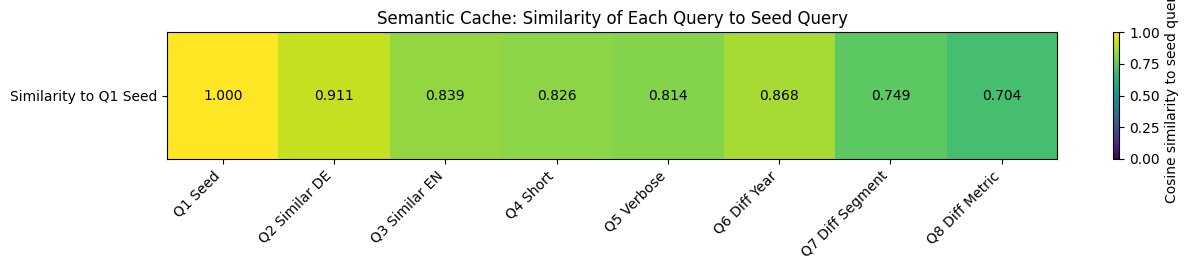

Embedding Q1_seed...
Embedding Q2_similar_de...
Embedding Q3_similar_en...
Embedding Q4_similar_short...
Embedding Q5_similar_verbose...
Embedding Q6_diff_year...
Embedding Q7_diff_segment...
Embedding Q8_diff_metric...
Embedding matrix shape: (8, 1536)


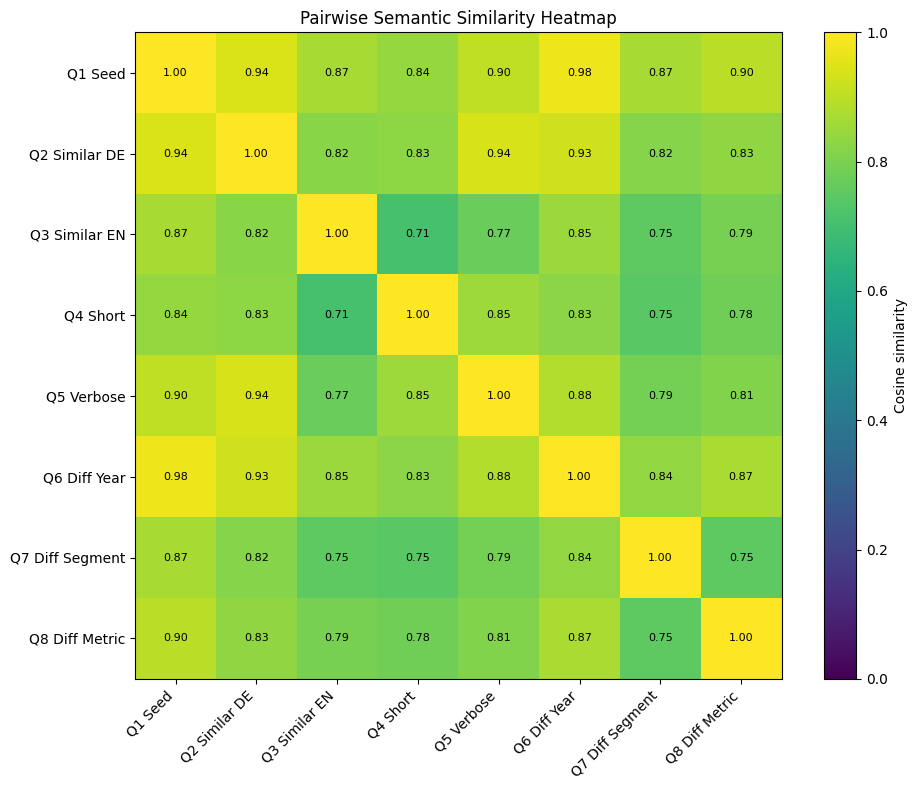

PCA explained variance:
PC1: 0.283
PC2: 0.230
Total: 0.513


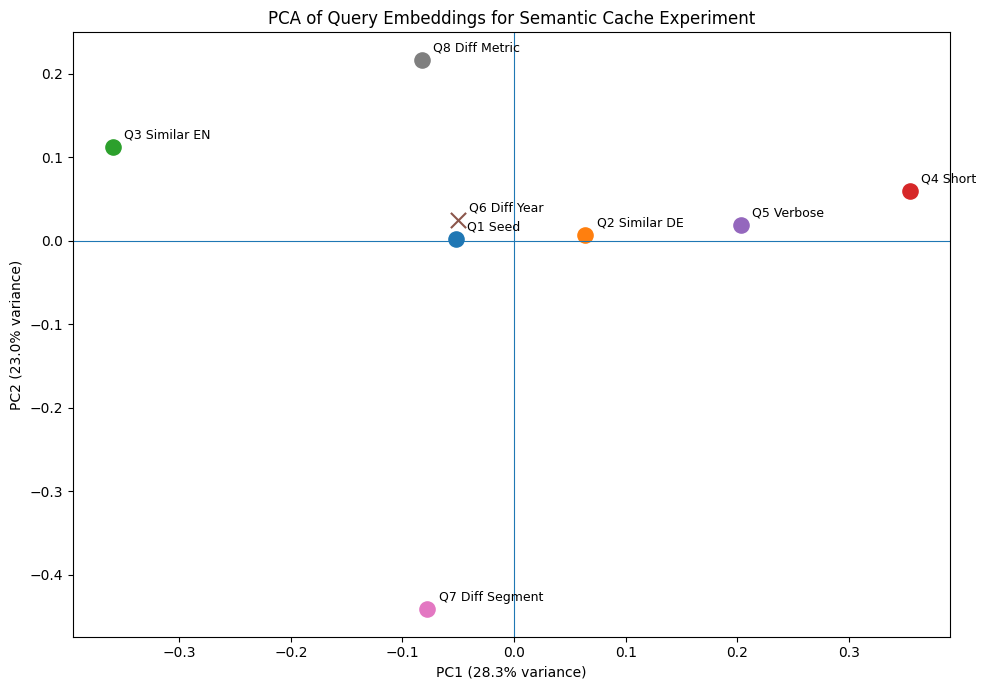

,Query,Note,Expected,Actual,Correct,Similarity_to_seed,Latency_s,Source,Rendered,PCA_PC1,PCA_PC2
0,Q1_seed,Seed query — populates cache,MISS,MISS,True,1.0000,52.522,LLM,True,-0.052144,0.001693
1,Q2_similar_de,"Same intent, different German wording",HIT,HIT,True,0.9110,2.001,cache,True,0.063958,0.007141
2,Q3_similar_en,"Same intent, English",HIT,HIT,True,0.8388,1.006,cache,True,-0.359609,0.112641
3,Q4_similar_short,"Short paraphrase, German",HIT,HIT,True,0.8264,0.272,cache,True,0.355062,0.059773
4,Q5_similar_verbose,"Verbose paraphrase, full JVA name",HIT,HIT,True,0.8138,0.191,cache,True,0.203234,0.018587
5,Q6_diff_year,Different year range — different scope,MISS,HIT,False,0.8680,0.190,cache,True,-0.050440,0.024866
6,Q7_diff_segment,Different segment — whole company,MISS,MISS,True,0.7492,29.779,LLM,False,-0.077612,-0.441306
7,Q8_diff_metric,Different metric — orders not revenue,MISS,MISS,True,0.7044,14.268,LLM,False,-0.082448,0.216605


Saved:
- cache_pca_summary.csv
- cache_pairwise_similarity_matrix.csv


In [1]:
# ============================================================
# Semantic Cache Visualization for cache_results.json
# Creates:
# 1) Seed similarity heatmap from JSON
# 2) Full pairwise cosine similarity heatmap using embeddings
# 3) PCA 2D embedding plot
# ============================================================

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Optional: only needed if your notebook uses .env
try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

# ------------------------------------------------------------
# 1. Load cache results JSON
# ------------------------------------------------------------

json_path = Path("cache_results.json")

# If your file is in /mnt/data, use this instead:
# json_path = Path("/mnt/data/cache_results.json")

with open(json_path, "r", encoding="utf-8") as f:
    cache_data = json.load(f)

c2_results = cache_data["C2"]["results"]
threshold = cache_data["C2"]["threshold"]

print(f"Loaded C2 cache experiment")
print(f"Configured threshold in JSON: {threshold}")

# ------------------------------------------------------------
# 2. Query text reconstruction
# IMPORTANT:
# Replace these texts with your exact queries if your notebook has them.
# PCA and full heatmap should use the real query texts.
# ------------------------------------------------------------

QUERY_TEXTS = {
    "Q1_seed": (
        "Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 "
        "im Segment JVA? Provide a detailed analysis and a comprehensive visualization."
    ),
    "Q2_similar_de": (
        "Wie hoch war der Umsatz von Teckentrup im Segment JVA zwischen 2021 und 2024? "
        "Bitte erstelle eine detaillierte Analyse und Visualisierung."
    ),
    "Q3_similar_en": (
        "How much revenue did Teckentrup have from 2021 to 2024 in the JVA segment? "
        "Provide a detailed analysis and comprehensive visualization."
    ),
    "Q4_similar_short": (
        "Umsatz Teckentrup JVA 2021 bis 2024 visualisieren."
    ),
    "Q5_similar_verbose": (
        "Bitte analysiere den Umsatz von Teckentrup im vollständigen Segment JVA "
        "für die Jahre 2021 bis 2024 und erstelle eine umfassende Visualisierung."
    ),
    "Q6_diff_year": (
        "Wieviel Umsatz hatte Teckentrup im Jahr 2024 im Segment JVA? "
        "Provide a detailed analysis and visualization."
    ),
    "Q7_diff_segment": (
        "Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 insgesamt "
        "für das gesamte Unternehmen? Provide a detailed analysis and visualization."
    ),
    "Q8_diff_metric": (
        "Wie viele Aufträge hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? "
        "Provide a detailed analysis and visualization."
    ),
}

# Keep only IDs that exist in the JSON
query_ids = [r["id"] for r in c2_results]
query_texts = [QUERY_TEXTS[qid] for qid in query_ids]

short_labels = [
    "Q1 Seed",
    "Q2 Similar DE",
    "Q3 Similar EN",
    "Q4 Short",
    "Q5 Verbose",
    "Q6 Diff Year",
    "Q7 Diff Segment",
    "Q8 Diff Metric",
]

# ------------------------------------------------------------
# 3. Create a simple seed similarity heatmap directly from JSON
# This does NOT need embeddings.
# It uses similarity values already saved in your cache_results.json.
# ------------------------------------------------------------

seed_similarities = []

for r in c2_results:
    if r["id"] == "Q1_seed":
        seed_similarities.append(1.0)
    else:
        seed_similarities.append(r["similarity"])

seed_similarities = np.array(seed_similarities).reshape(1, -1)

plt.figure(figsize=(13, 2.8))
plt.imshow(seed_similarities, aspect="auto", vmin=0, vmax=1)
plt.colorbar(label="Cosine similarity to seed query")

plt.xticks(range(len(short_labels)), short_labels, rotation=45, ha="right")
plt.yticks([0], ["Similarity to Q1 Seed"])
plt.title("Semantic Cache: Similarity of Each Query to Seed Query")

for i, value in enumerate(seed_similarities[0]):
    plt.text(i, 0, f"{value:.3f}", ha="center", va="center")

plt.axhline(-0.5)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Get embeddings for all query texts
# This is needed for full heatmap and PCA.
# ------------------------------------------------------------

from openai import OpenAI

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

EMBEDDING_MODEL = "text-embedding-3-small"

def get_embedding(text):
    response = client.embeddings.create(
        model=EMBEDDING_MODEL,
        input=text
    )
    return response.data[0].embedding

embeddings = []

for qid, text in zip(query_ids, query_texts):
    print(f"Embedding {qid}...")
    emb = get_embedding(text)
    embeddings.append(emb)

embeddings = np.array(embeddings, dtype=float)

print("Embedding matrix shape:", embeddings.shape)

# ------------------------------------------------------------
# 5. Pairwise cosine similarity heatmap
# ------------------------------------------------------------

def cosine_similarity_matrix(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    X_norm = X / norms
    return np.dot(X_norm, X_norm.T)

sim_matrix = cosine_similarity_matrix(embeddings)

plt.figure(figsize=(10, 8))
plt.imshow(sim_matrix, vmin=0, vmax=1)
plt.colorbar(label="Cosine similarity")

plt.xticks(range(len(short_labels)), short_labels, rotation=45, ha="right")
plt.yticks(range(len(short_labels)), short_labels)
plt.title("Pairwise Semantic Similarity Heatmap")

for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        plt.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. PCA analysis
# ------------------------------------------------------------

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

explained = pca.explained_variance_ratio_

print(f"PCA explained variance:")
print(f"PC1: {explained[0]:.3f}")
print(f"PC2: {explained[1]:.3f}")
print(f"Total: {explained.sum():.3f}")

# Prepare labels for HIT/MISS/correctness from JSON
expected = [r["expected"] for r in c2_results]
actual = [r["actual"] for r in c2_results]
correct = [r["correct"] for r in c2_results]

plt.figure(figsize=(10, 7))

for i, qid in enumerate(query_ids):
    marker = "o" if correct[i] else "x"
    plt.scatter(coords[i, 0], coords[i, 1], marker=marker, s=120)
    plt.text(coords[i, 0] + 0.01, coords[i, 1] + 0.01, short_labels[i], fontsize=9)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
plt.title("PCA of Query Embeddings for Semantic Cache Experiment")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Create a summary table for thesis interpretation
# ------------------------------------------------------------

import pandas as pd

summary_rows = []

for i, r in enumerate(c2_results):
    summary_rows.append({
        "Query": r["id"],
        "Note": r["note"],
        "Expected": r["expected"],
        "Actual": r["actual"],
        "Correct": r["correct"],
        "Similarity_to_seed": 1.0 if r["id"] == "Q1_seed" else r["similarity"],
        "Latency_s": r["latency_s"],
        "Source": r["source"],
        "Rendered": r["rendered"],
        "PCA_PC1": coords[i, 0],
        "PCA_PC2": coords[i, 1],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# Optional: save outputs
summary_df.to_csv("cache_pca_summary.csv", index=False)
np.savetxt("cache_pairwise_similarity_matrix.csv", sim_matrix, delimiter=",")

print("Saved:")
print("- cache_pca_summary.csv")
print("- cache_pairwise_similarity_matrix.csv")